# Violence Detection — Experimentation Notebook

Binary (violent / non-violent) video classification on RWF-2000. This notebook is for experimentation, visualisation, debugging and analysis; all production logic lives in the `.py` modules and is imported here, never duplicated.

## 1. Project setup

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = "/content/violence_detection"  # edit if you cloned/uploaded elsewhere
    if not os.path.exists(PROJECT_ROOT):
        raise FileNotFoundError(
            "Clone or upload the project to this path first, e.g.:\n"
            "  !git clone <this-repo> /content/violence_detection\n"
            "or edit PROJECT_ROOT above to match where you placed it."
        )
else:
    PROJECT_ROOT = os.path.abspath("")

sys.path.append(PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)

Project root: /home/pp26/violence_detection/violence_detection


## 2. Imports

In [2]:
import json

import numpy as np
import matplotlib.pyplot as plt
import torch

from config.config import Config, get_default_config
from data.splits import build_sample_lists
from data.dataset import RWFVideoDataset
from data.transforms import ClipTrainTransform, ClipEvalTransform, IMAGENET_MEAN, IMAGENET_STD
from data.dataloaders import build_dataloaders
from models.build import build_model
from training.trainer import Trainer
from training.metrics import compute_binary_metrics, find_threshold_for_recall
from utils.seed import set_seed
from utils.device import get_device
from utils.model_utils import count_parameters
from utils.checkpoint import load_checkpoint
from utils.history import load_history, plot_training_curves, plot_comparison
from inference.predict import ViolenceDetector
from evaluate import run_evaluation

## 3. Configuration

Sections 4-11 below walk through the pipeline step by step for a single architecture (`ARCHITECTURE`), to inspect data and a freshly-built model up close. Section 12 then trains **both** architectures back to back for comparison.

**Note on batch size:** `get_default_config` returns the batch sizes this project was tuned with on a 16GB GPU (32 for `lightweight_tsm`, 8 for `backbone_transformer`). This notebook overrides them to a small value so interactive experimentation is fast and works on any machine, including a CPU-only laptop - depthwise-separable convolutions (used throughout `lightweight_tsm`) are notably memory-hungry in PyTorch's CPU backend (this is a PyTorch/CPU characteristic, not specific to this model - GPU training does not have this issue). Raise `batch_size` back up when running a real training job via `train.py` on the GPU.

In [3]:
ARCHITECTURE = "lightweight_tsm"  # or "backbone_transformer"

config = get_default_config(ARCHITECTURE)
config.data.data_root = "./data/RWF-2000"  # point this at your extracted dataset
config.training.num_epochs = 2  # keep small for interactive experimentation; raise for a real run
config.training.batch_size = 32  # small and fast for this notebook; see note above

# Multiprocessing DataLoader workers fork after the Jupyter kernel has already
# started, which can crash the kernel. Scripts (train.py) don't have this
# restriction and can safely use config.data.num_workers > 0.
config.data.num_workers = 1

print(json.dumps(config.to_dict(), indent=2))

{
  "data": {
    "data_root": "./data/RWF-2000",
    "train_dir": "train",
    "val_dir": "val",
    "class_names": [
      "NonFight",
      "Fight"
    ],
    "num_frames": 16,
    "frame_size": 112,
    "val_ratio": 0.1,
    "num_workers": 1,
    "pin_memory": true
  },
  "model": {
    "architecture": "lightweight_tsm",
    "pretrained": false,
    "freeze_backbone_epochs": 5,
    "unfreeze_num_stages": 2,
    "d_model": 256,
    "n_heads": 8,
    "n_layers": 4,
    "ff_dim": 1024,
    "transformer_dropout": 0.1,
    "width_mult": 1.0,
    "classifier_dropout": 0.3
  },
  "training": {
    "seed": 42,
    "batch_size": 32,
    "num_epochs": 2,
    "optimizer": "sgd",
    "learning_rate": 0.05,
    "backbone_learning_rate": 1e-05,
    "weight_decay": 5e-05,
    "warmup_ratio": 0.05,
    "grad_clip_norm": 1.0,
    "loss": "bce",
    "focal_gamma": 2.0,
    "focal_alpha": 0.25,
    "mixed_precision": true,
    "early_stopping_patience": 8,
    "monitor_metric": "f1",
    "decision_th

## 4. Random seeds

In [4]:
set_seed(config.training.seed)
print(f"Seeded Python/NumPy/PyTorch with seed={config.training.seed}")

Seeded Python/NumPy/PyTorch with seed=42


## 5. Dataset inspection

In [5]:
train_samples, val_samples, test_samples = build_sample_lists(config.data, config.training.seed)
print(f"train: {len(train_samples)}  val: {len(val_samples)}  test: {len(test_samples)}")

train: 1440  val: 160  test: 400


## 6. Exploratory data analysis

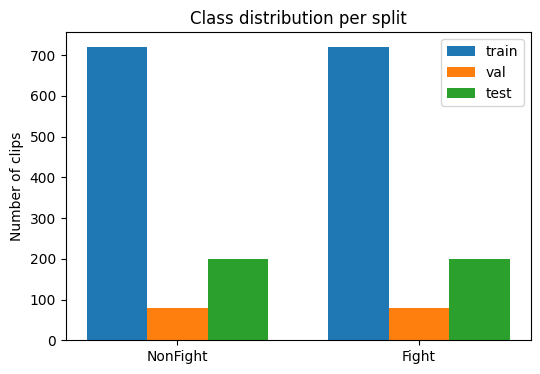

In [6]:
def class_counts(samples):
    counts = [0, 0]
    for _, label in samples:
        counts[label] += 1
    return counts

splits = {"train": train_samples, "val": val_samples, "test": test_samples}
fig, ax = plt.subplots(figsize=(6, 4))
width = 0.25
for i, (name, samples) in enumerate(splits.items()):
    counts = class_counts(samples)
    ax.bar(np.arange(2) + i * width, counts, width=width, label=name)
ax.set_xticks(np.arange(2) + width)
ax.set_xticklabels(config.data.class_names)
ax.set_ylabel("Number of clips")
ax.set_title("Class distribution per split")
ax.legend()
plt.show()

## 7. Data preprocessing

In [7]:
train_transform = ClipTrainTransform(config.data.frame_size)
eval_transform = ClipEvalTransform(config.data.frame_size)
print("Train transform resize/crop size:", config.data.frame_size)

Train transform resize/crop size: 112


## 8. Sample visualization

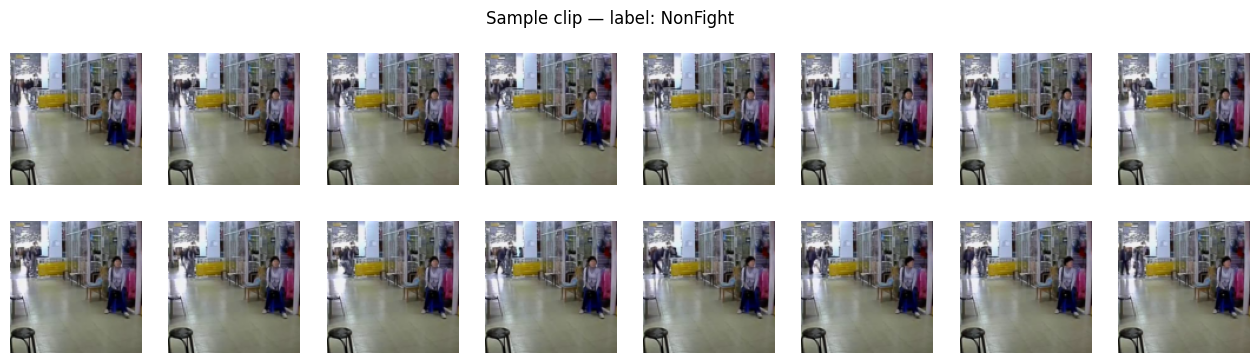

In [8]:
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

preview_dataset = RWFVideoDataset([train_samples[0]], config.data.num_frames, eval_transform, train=False)
clip_tensor, label = preview_dataset[0]

n_cols = min(8, config.data.num_frames)
n_rows = max(1, config.data.num_frames // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows))
for i, ax in enumerate(np.array(axes).flat):
    frame = (clip_tensor[i] * std + mean).clamp(0, 1)
    ax.imshow(frame.permute(1, 2, 0).numpy())
    ax.axis("off")
fig.suptitle(f"Sample clip — label: {config.data.class_names[int(label)]}")
plt.show()

## 9. Dataset and DataLoader creation

In [9]:
train_loader, val_loader, test_loader = build_dataloaders(config)
clips, labels = next(iter(train_loader))
print("Batch clip shape:", clips.shape, "| labels shape:", labels.shape)

Batch clip shape: torch.Size([32, 16, 3, 112, 112]) | labels shape: torch.Size([32])


## 10. Model definition / import

In [10]:
model = build_model(config)
print(model.__class__.__name__)

LightweightTSMNet


## 11. Model summary

In [11]:
# total_params, trainable_params = count_parameters(model)
# print(f"Total parameters: {total_params:,}")
# print(f"Trainable parameters: {trainable_params:,}")
# print(model)

## 12. Training

Trains **both** architectures one after another and keeps every result (config, model, device, loaders, history) in `experiment_results`, keyed by architecture name, so the rest of the notebook can compare them.

Each architecture gets its own `experiment_name` (`get_default_config` already sets this to the architecture name), so their `history.jsonl` files never mix - `Trainer` also truncates any stale history left over from an older run under the same name before writing new epochs, so re-running this cell is always safe.

In [12]:
def configure_lightweight_run1(run_config):
    run_config.training.num_epochs = 2 #50
    run_config.training.batch_size = 32
    run_config.data.num_workers = 1


def configure_lightweight_run2(run_config):
    run_config.training.monitor_metric = "f2"
    run_config.training.learning_rate = 0.11
    run_config.training.num_epochs = 2 #50
    run_config.training.batch_size = 70
    run_config.data.num_workers = 1


def configure_backbone_run1(run_config):
    run_config.model.unfreeze_num_stages = 1
    run_config.model.transformer_dropout = 0.2
    run_config.model.classifier_dropout = 0.4
    run_config.model.freeze_backbone_epochs = 8
    run_config.training.weight_decay = 5e-4
    run_config.training.backbone_learning_rate = 5e-6
    run_config.training.monitor_metric = "f2"
    run_config.training.num_epochs = 2 #25
    run_config.training.batch_size = 27
    run_config.data.num_workers = 1


# (name, architecture, configure_fn) - add more tuples to try more configurations.
EXPERIMENTS = [
    ("lightweight_tsm_run1", "lightweight_tsm", configure_lightweight_run1),
    ("lightweight_tsm_run2", "lightweight_tsm", configure_lightweight_run2),
    ("backbone_transformer_run1", "backbone_transformer", configure_backbone_run1),
]

In [13]:
device = get_device()
print("Training on:", device)

experiment_results = {}
for name, architecture, configure_fn in EXPERIMENTS:
    print(f"\n{'=' * 20} {name} ({architecture}) {'=' * 20}")
    run_config = get_default_config(architecture)
    run_config.data.data_root = "./data/RWF-2000"
    configure_fn(run_config)

    set_seed(run_config.training.seed)
    run_train_loader, run_val_loader, run_test_loader = build_dataloaders(run_config)
    run_model = build_model(run_config)

    run_trainer = Trainer(run_model, run_train_loader, run_val_loader, run_config, device)
    run_trainer.fit()

    experiment_results[name] = {
        "config": run_config,
        "model": run_model,
        "trainer": run_trainer,
        "test_loader": run_test_loader,
    }
# for architecture in ["lightweight_tsm", "backbone_transformer"]:# 
#     print(f"\n{'=' * 20} {architecture} {'=' * 20}")
#     run_config = get_default_config(architecture)
#     run_config.data.data_root = "./data/RWF-2000"

#     if architecture == "lightweight_tsm":
#         run_config.training.num_epochs = 2 #50
#         run_config.training.batch_size = 32
#         run_config.data.num_workers = 1
#     elif architecture == "backbone_transformer":
#         run_config.model.unfreeze_num_stages = 1
#         run_config.model.transformer_dropout = 0.2
#         run_config.model.classifier_dropout = 0.4
#         run_config.model.freeze_backbone_epochs = 8
#         run_config.training.weight_decay = 5e-4
#         run_config.training.backbone_learning_rate = 5e-6
#         run_config.training.monitor_metric = "f2"
#         run_config.training.num_epochs = 2 #25
#         run_config.training.batch_size = 27
#         run_config.data.num_workers = 1


#     set_seed(run_config.training.seed)
#     run_train_loader, run_val_loader, run_test_loader = build_dataloaders(run_config)
#     run_model = build_model(run_config)

#     run_trainer = Trainer(run_model, run_train_loader, run_val_loader, run_config, device)
#     run_trainer.fit()

#     experiment_results[architecture] = {
#         "config": run_config,
#         "model": run_model,
#         "trainer": run_trainer,
#         "test_loader": run_test_loader,
#     }

print("\nDone training all architectures.")

Training on: cuda

==================== lightweight_tsm_run1 (lightweight_tsm) ====================


KeyboardInterrupt: 

## 13. Training curves

`load_history` returns only the most recent contiguous run for an experiment name (defending against older log files that mixed multiple runs together - the cause of a jagged, backtracking line if you've seen one), and `plot_training_curves` draws the loss and validation-metric panels together.

In [ ]:
histories = {}
for architecture, run in experiment_results.items():
    histories[architecture] = load_history(run["config"].paths.log_dir, run["config"].paths.experiment_name)
    plot_training_curves(histories[architecture], title=architecture)

In [ ]:
# Overlay both architectures on the same axes for a direct comparison.
plot_comparison(histories, metric_key="val_f1")
plot_comparison(histories, metric_key="val_recall")

## 14. Validation results

A side-by-side table of each architecture's *best* epoch (by `monitor_metric`) rather than just its last one, since the last epoch isn't always the best (see the overfitting discussion for `backbone_transformer` in your own runs).

In [ ]:
monitor_metric = config.training.monitor_metric
print(f"{'architecture':<22}{'best_epoch':<12}{'val_f1':<10}{'val_f2':<10}{'val_recall':<12}{'val_roc_auc':<12}")
for architecture, records in histories.items():
    best_record = max(records, key=lambda r: r[f"val_{monitor_metric}"])
    print(
        f"{architecture:<22}{best_record['epoch']:<12}"
        f"{best_record['val_f1']:<10.4f}{best_record['val_f2']:<10.4f}"
        f"{best_record['val_recall']:<12.4f}{best_record['val_roc_auc']:<12.4f}"
    )

## 15. Error analysis

Pick one architecture to dig into for the remaining sections. Runs the model over the validation split one clip at a time (rather than in shuffled batches) so each prediction can be traced back to its source file. For a large validation set, slice `val_samples[:200]` first to keep this quick.

In [ ]:
INSPECT_ARCHITECTURE = "lightweight_tsm"  # or "backbone_transformer"

config = experiment_results[INSPECT_ARCHITECTURE]["config"]
model = experiment_results[INSPECT_ARCHITECTURE]["model"]
test_loader = experiment_results[INSPECT_ARCHITECTURE]["test_loader"]
eval_transform = ClipEvalTransform(config.data.frame_size)
_, val_samples, test_samples = build_sample_lists(config.data, config.training.seed)

val_dataset_named = RWFVideoDataset(val_samples, config.data.num_frames, eval_transform, train=False)
model.eval()
predictions = []
with torch.no_grad():
    for i in range(len(val_dataset_named)):
        clip, _ = val_dataset_named[i]
        probability = torch.sigmoid(model(clip.unsqueeze(0).to(device))).item()
        path, true_label = val_samples[i]
        predictions.append({"path": path, "label": true_label, "probability": probability})

misclassified = [r for r in predictions if (r["probability"] >= 0.5) != bool(r["label"])]
missed_fights = [r for r in misclassified if r["label"] == 1]  # false negatives - the costly kind here
misclassified.sort(key=lambda r: abs(r["probability"] - r["label"]), reverse=True)
print(f"{len(misclassified)} / {len(predictions)} validation clips misclassified")
print(f"Of these, {len(missed_fights)} are missed real fights (false negatives) - the ones to look at first.")
for r in misclassified[:5]:
    print(r)

## 16. Final evaluation

Reports test-set metrics at the default 0.5 threshold, then also at the threshold `find_threshold_for_recall` suggests for hitting a target recall - useful here since a missed real fight (false negative) is worse than a false alarm, so it's often worth deliberately trading some precision for recall.

In [ ]:
test_metrics = run_evaluation(model, test_loader, device)
print("At threshold 0.5:")
print(json.dumps({k: v for k, v in test_metrics.items() if k != "confusion_matrix"}, indent=2))

cm = np.array(test_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap="Blues")
for (i, j), value in np.ndenumerate(cm):
    ax.text(j, i, str(value), ha="center", va="center")
ax.set_xticks([0, 1]); ax.set_xticklabels(config.data.class_names)
ax.set_yticks([0, 1]); ax.set_yticklabels(config.data.class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix — test split (threshold 0.5)")
plt.show()

In [ ]:
TARGET_RECALL = 0.95  # e.g. "miss at most 5% of real fights"

y_true, y_prob = [], []
model.eval()
with torch.no_grad():
    for clips, labels in test_loader:
        probabilities = torch.sigmoid(model(clips.to(device))).cpu().numpy()
        y_true.append(labels.numpy())
        y_prob.append(probabilities)
y_true, y_prob = np.concatenate(y_true), np.concatenate(y_prob)

suggested_threshold = find_threshold_for_recall(y_true, y_prob, TARGET_RECALL)
recall_metrics = compute_binary_metrics(y_true, y_prob, threshold=suggested_threshold)
print(f"Suggested threshold for >= {TARGET_RECALL:.0%} recall: {suggested_threshold:.3f}")
print(json.dumps(recall_metrics, indent=2))

## 17. Example predictions

In [ ]:
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

n_examples = min(4, len(test_samples))
fig, axes = plt.subplots(1, n_examples, figsize=(4 * n_examples, 4))
for ax, (path, true_label) in zip(np.array(axes).flat, test_samples[:n_examples]):
    single = RWFVideoDataset([(path, true_label)], config.data.num_frames, eval_transform, train=False)
    clip, _ = single[0]
    with torch.no_grad():
        probability = torch.sigmoid(model(clip.unsqueeze(0).to(device))).item()
    middle_frame = (clip[len(clip) // 2] * std + mean).clamp(0, 1)
    ax.imshow(middle_frame.permute(1, 2, 0).numpy())
    predicted = config.data.class_names[int(probability >= 0.5)]
    ax.set_title(f"true={config.data.class_names[true_label]}\npred={predicted} ({probability:.2f})")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 18. Model checkpoint loading

In [ ]:
best_checkpoint_path = f"{config.paths.checkpoint_dir}/{config.paths.experiment_name}/best.pt"
reloaded_model = build_model(config).to(device)
checkpoint_info = load_checkpoint(best_checkpoint_path, reloaded_model, map_location=device)
print("Loaded checkpoint from epoch:", checkpoint_info["epoch"], "| best_metric:", checkpoint_info["best_metric"])

## 19. Inference examples

In [ ]:
detector = ViolenceDetector(best_checkpoint_path, device=device)
example_path, example_label = test_samples[0]
prediction = detector.predict(example_path)
print("Ground truth:", config.data.class_names[example_label])
print("Prediction:", prediction)

## 20. Conclusions

_Summarise your findings here once you have real training runs to compare, e.g.:_

- Final test accuracy / F1 / F2 / recall / ROC-AUC for each architecture (§14, §16).
- Which architecture trained faster and which reached a higher ceiling.
- Whether `backbone_transformer` showed the train/val loss divergence (overfitting) pattern, and what reduced it (more dropout/weight decay, fewer unfrozen stages, ...).
- The precision/recall trade-off at your chosen threshold (§16) - is missing a real fight (false negative) or a false alarm (false positive) more costly for your use case?
- Recurring patterns in the misclassified clips from §15 (lighting, crowd density, camera motion, ...).
- Next steps: more augmentation, a different frame count, ensembling both architectures, etc.